In [1]:
import pandas as pd

rfm = pd.read_parquet("../data/processed/customer_segments.parquet")

# X = the clues the model learns from. y = the answer it's predicting.
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Is_Churned']

print("Feature shape:", X.shape)
print("Churn balance:\n", y.value_counts())

Feature shape: (4979, 3)
Churn balance:
 Is_Churned
0    2577
1    2402
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,      # hold back 25% to test on
    random_state=42,     # repeatable
    stratify=y           # keep the same churn ratio in both halves
)

print("Training customers:", len(X_train))
print("Test customers:", len(X_test))

Training customers: 3734
Test customers: 1245


In [3]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_bal.value_counts())

Before SMOTE:
 Is_Churned
0    1933
1    1801
Name: count, dtype: int64

After SMOTE:
 Is_Churned
0    1933
1    1933
Name: count, dtype: int64


In [4]:
from xgboost import XGBClassifier

# Tuned via 5-fold RandomizedSearchCV against the 180-day churn label.
# XGBoost's defaults (depth 6, lr 0.3, 100 trees) are built for wide feature
# sets and badly overfit just three columns — shallow trees, a slow learning
# rate and regularization lift ROC-AUC from ~0.76 to ~0.81.
model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=1.0,
    reg_lambda=5,
    gamma=2,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_bal, y_train_bal)
print("Model trained.")

Model trained.


In [5]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # probability of churn, 0 to 1

print("Predictions made on", len(y_test), "unseen customers.")

Predictions made on 1245 unseen customers.


In [6]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.68      0.73       644
           1       0.70      0.79      0.74       601

    accuracy                           0.73      1245
   macro avg       0.74      0.74      0.73      1245
weighted avg       0.74      0.73      0.73      1245

ROC-AUC: 0.813

Confusion matrix:
 [[439 205]
 [125 476]]


In [7]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# A single 25% holdout on 1,321 customers is noisy. 5-fold CV on all the data
# gives a more trustworthy number to quote.
cv_scores = cross_val_score(
    model, X, y,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
print("5-fold ROC-AUC:", cv_scores.round(3))
print("Mean:", round(cv_scores.mean(), 3), "+/-", round(cv_scores.std(), 3))

5-fold ROC-AUC: [0.813 0.806 0.833 0.818 0.798]
Mean: 0.814 +/- 0.012


In [8]:
# The 0.5 default is an arbitrary cut. Sweep every threshold and save the curve
# so the app can show what a chosen cutoff costs in precision and buys in recall.
#
# Built from out-of-fold predictions rather than the single 25% test split: every
# customer gets a prediction from a model that never saw them, so the curve rests
# on all 5,000 rather than 1,245 and the extreme thresholds stop being noise.
# SMOTE sits inside the pipeline so it re-fits per fold on training data only —
# resampling before the split would leak synthetic rows across folds.
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_predict
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone

oof_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', clone(model)),
])
y_proba_oof = cross_val_predict(
    oof_pipeline, X, y,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    method='predict_proba',
)[:, 1]

print("Out-of-fold predictions for", len(y_proba_oof), "customers")
print("Out-of-fold ROC-AUC:", round(roc_auc_score(y, y_proba_oof), 3))

precision, recall, thresholds = precision_recall_curve(y, y_proba_oof)
# precision_recall_curve returns one extra point with no threshold — drop it
curve = pd.DataFrame({
    'threshold': thresholds,
    'precision': precision[:-1],
    'recall': recall[:-1],
})
curve['f1'] = 2 * curve.precision * curve.recall / (curve.precision + curve.recall)

best = curve.loc[curve.f1.idxmax()]
print("\nBest-F1 threshold:", round(best.threshold, 2),
      "| precision", round(best.precision, 2), "| recall", round(best.recall, 2))

# round to 2dp so the app can look up any slider position directly
curve['threshold'] = curve['threshold'].round(2)
lookup = curve.groupby('threshold')[['precision', 'recall', 'f1']].mean().round(4)
lookup['n_flagged'] = [int((y_proba_oof >= t).sum()) for t in lookup.index]

print(lookup.loc[0.20:0.90:5].to_string())
# n_flagged lets the app quote a real campaign size, so keep it
lookup['n_total'] = len(y)
lookup.to_json("../models/threshold_curve.json", orient='index')
print("\nSaved threshold curve for the app.")

Out-of-fold predictions for 4979 customers
Out-of-fold ROC-AUC: 0.812

Best-F1 threshold: 0.38 | precision 0.65 | recall 0.88
           precision  recall      f1  n_flagged
threshold                                      
0.20          0.5896  0.9619  0.7311       3920
0.25          0.6067  0.9469  0.7396       3747
0.30          0.6225  0.9227  0.7435       3559
0.35          0.6392  0.8959  0.7461       3363
0.40          0.6596  0.8683  0.7497       3159
0.45          0.6744  0.8350  0.7462       2977
0.50          0.6962  0.7842  0.7376       2716
0.55          0.7227  0.7121  0.7174       2372
0.60          0.7503  0.6452  0.6938       2060
0.65          0.7745  0.5595  0.6496       1729
0.70          0.8037  0.4642  0.5885       1398
0.75          0.8334  0.3681  0.5106       1061
0.80          0.8567  0.3041  0.4488        856
0.85          0.8834  0.2080  0.3366        565
0.90          0.8710  0.0777  0.1426        201

Saved threshold curve for the app.


In [9]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importances)

     Feature  Importance
1  Frequency    0.608408
0    Recency    0.224270
2   Monetary    0.167322


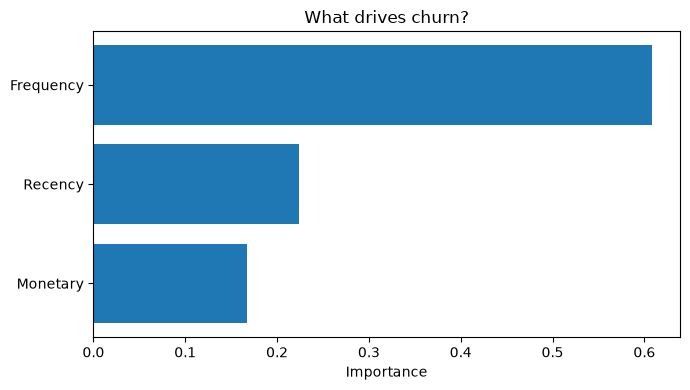

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.barh(importances['Feature'], importances['Importance'])
plt.xlabel('Importance')
plt.title('What drives churn?')
plt.gca().invert_yaxis()  # biggest bar on top
plt.tight_layout()
plt.savefig("../reports/feature_importance.png", dpi=150)
plt.show()

In [11]:
import joblib

joblib.dump(model, "../models/churn_model.pkl")
print("Model saved. Phase 3 complete.")

Model saved. Phase 3 complete.
